In [1]:
from OOP_so_far import RunSSA, ModuleProperties, CombiningModules, plot_combined_conductance
from sympy import *
import numpy as np
import time

/Users/willalston/Desktop/Msci_Project/git_repos/students/Will/Gillespie_simulations/OOP_so_far.py:1338: SyntaxWarning: invalid escape sequence '\m'
  chem_pot = symbols(f"\mu_{species_symbol}")


In [2]:
# MODULE 1


SM = Matrix( [[-1,1,0], [1,-1,-1], [0,0,1], [-1,0,-1], [0,1,0]])

species_names = ["Ea", "EaS","EaS2","S","Na"]

num_internal_species = 3


# MODULE 2

SM2 = Matrix([[-1, 0, 1, 0, 0], # first row of internal
                           [1, -1, 0, -1, 0], 
                           [0, 1, -1, 0, 1], 
                           [0, 0, 0, 1, -1],
                             [0, 0, 0, -1, 0], # first row external 
                             [0, 0, 0, 0, 1],
                             [-1, 0, 0, 0, 0],
                             [0, 0, 1, 0, 0]])


species_names2 = ["Eb", "EbF", "EbW", "Eb*", "Na", "Nb", "F", "W"]

num_internal_species2 = 4

# Use ModuleProperties to create module variables for our CRNs




# Define the initial conditions we need to simulate our CRNs using the SSA

simulation_length = 800.0

burn_in_time = 200.0 # This quantity is important for ensuring we are sampling the steady state - it is best to first pick any value
                     # burn_in_time < simulation_length, visually see where the transient state ends on the counts plot, and then
                     # adjust this value appropriately for sampling runs.

initial_counts = [350, 350, 350, 50, 50]
# initial counts for numerical comparison: Na =  66.81977526898818
# initial_counts = [350, 350, 350, 50, 66.81977526898818]


rates = 0.1 * np.array([0.005, 0.8, 0.6, 0.002, 0.012, 0.5])


# initial counts for numerical comparison: Na =  66.81977526898818
initial_counts2 = [350, 350, 350, 350, 50, 50, 50, 50]
# initial_counts2 = [350, 350, 350, 350, 66.81977526898818, 50, 50, 50]

rates2 = 0.1 * np.array([0.01, 1.0, 1.0, 0.5, 1.5, 0.01, 0.01, 1.0, 1.2, 0.01])


# First, create the following module variables for the two CRNs we want to combine.

module1_for_simulating = ModuleProperties(SM, 3, species_names)

module2_for_simulating = ModuleProperties(SM2, 4, species_names2)

# We must create the individual resistance matrices for each module before combining them

module1_for_simulating.calculate_fundamental_resistance_matrix() 

module2_for_simulating.calculate_fundamental_resistance_matrix()

# Then prepare the module variables for simulation

SIM1 = RunSSA(module1_for_simulating, initial_counts, rates, simulation_length, burn_in_time)

SIM2 = RunSSA(module2_for_simulating, initial_counts2, rates2, simulation_length, burn_in_time)




In [57]:
# Compute data that will be combined. 



# Module 1

SIM1.run_IF_sweep(

        species_index=[3,4],
        count_values=[np.linspace(50,500,50,dtype='int'), Na_SS],
        total_iterations=25, 
        covariance_reaction_indices=[0],   
        verbose=True)

# Module 2

SIM2.run_IF_sweep(

        species_index=[4,5],
        count_values=[Na_SS, np.linspace(50,500,50,dtype='int')],
        total_iterations=25, 
        covariance_reaction_indices=[2,4],   
        verbose=True)

Sweep 1/50  ([S] = 50, [Na] = 67)
Sweep 2/50  ([S] = 59, [Na] = 79)
Sweep 3/50  ([S] = 68, [Na] = 90)
Sweep 4/50  ([S] = 77, [Na] = 102)
Sweep 5/50  ([S] = 86, [Na] = 111)
Sweep 6/50  ([S] = 95, [Na] = 123)
Sweep 7/50  ([S] = 105, [Na] = 133)
Sweep 8/50  ([S] = 114, [Na] = 145)
Sweep 9/50  ([S] = 123, [Na] = 154)
Sweep 10/50  ([S] = 132, [Na] = 165)
Sweep 11/50  ([S] = 141, [Na] = 175)
Sweep 12/50  ([S] = 151, [Na] = 186)
Sweep 13/50  ([S] = 160, [Na] = 195)
Sweep 14/50  ([S] = 169, [Na] = 205)
Sweep 15/50  ([S] = 178, [Na] = 215)
Sweep 16/50  ([S] = 187, [Na] = 226)
Sweep 17/50  ([S] = 196, [Na] = 235)
Sweep 18/50  ([S] = 206, [Na] = 245)
Sweep 19/50  ([S] = 215, [Na] = 255)
Sweep 20/50  ([S] = 224, [Na] = 264)
Sweep 21/50  ([S] = 233, [Na] = 274)
Sweep 22/50  ([S] = 242, [Na] = 282)
Sweep 23/50  ([S] = 252, [Na] = 292)
Sweep 24/50  ([S] = 261, [Na] = 305)
Sweep 25/50  ([S] = 270, [Na] = 310)
Sweep 26/50  ([S] = 279, [Na] = 325)
Sweep 27/50  ([S] = 288, [Na] = 333)
Sweep 28/50  ([S] =

(array([[6.3583116 , 4.82331685, 6.30997843, 1.55332802, 1.51499482],
        [6.35159496, 5.196608  , 6.38826121, 1.22331952, 1.19665316],
        [5.7783305 , 4.84166429, 5.81166382, 0.93666621, 0.97333286],
        [6.26665809, 4.46832722, 6.26499143, 1.80999752, 1.81166419],
        [6.13832797, 4.6899959 , 6.10166133, 1.44333207, 1.45333206],
        [5.95499553, 4.68499649, 5.97832885, 1.27666571, 1.23999907],
        [5.93999808, 4.79499845, 5.92499809, 1.17166629, 1.11499964],
        [6.2615562 , 5.02157807, 6.18822416, 1.23997812, 1.12998006],
        [6.2832491 , 4.65493759, 6.28658239, 1.61497835, 1.59497862],
        [6.50332686, 4.4916622 , 6.44832692, 1.98833136, 1.95999805],
        [5.81499831, 4.33999874, 5.74499833, 1.46499957, 1.42999958],
        [6.04827588, 5.00328581, 6.01660952, 1.09332295, 1.04499007],
        [5.97664857, 4.93331839, 5.95498197, 1.05833013, 1.02833022],
        [6.18996716, 4.73497488, 6.25496682, 1.49165875, 1.49499207],
        [5.93666663,

In [ ]:


# Compute lists of the numerical conductance for each module, we will not overlay any analytical results.

module1_conductances, _ = SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

module2_conductances, _ = SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

# Now we use the CombiningModules class to combine the data from the two modules, this essentially involves replacing the symbolic
# values of resistance with the numerical results calculated above, and the same code as the symbolic case follows.

module3 = CombiningModules(module1_for_simulating, module2_for_simulating, module1_conductances, module2_conductances)

# Store the numerical combined condictance matrices

combined_Gs = module3.numerical_combined_fundamental_CMs# Acquire the serially combined conductance matrices

analytical_G_np = np.array(combined_Gs, dtype=float)
eigenvalues = np.array([np.linalg.eigvals(analytical_G_np[i]) 
                            for i in range(analytical_G_np.shape[0])])

eigenvalues


array([[ 2.83718479, 10.05901375],
       [ 2.99101855, 10.0031756 ],
       [ 3.15108836, 10.00045429],
       [ 3.26780239,  9.90863316],
       [ 3.32261781,  9.85512396],
       [ 3.34930837,  9.75446545],
       [ 3.38326533,  9.6850811 ],
       [ 3.39638171,  9.58976768],
       [ 3.36529123,  9.47084682],
       [ 3.31115222,  9.32575898],
       [ 3.30166114,  9.2438702 ],
       [ 3.27881529,  9.13331744],
       [ 3.20164896,  8.96083568],
       [ 3.23990322,  8.91140839],
       [ 3.12642223,  8.72735141],
       [ 3.13159609,  8.67415329],
       [ 3.0425518 ,  8.4885746 ],
       [ 2.98579914,  8.35890608],
       [ 2.97195141,  8.24880406],
       [ 2.94065457,  8.20950535],
       [ 2.87538223,  8.04789994],
       [ 2.78104383,  7.94233554],
       [ 2.77835718,  7.81472598],
       [ 2.74237889,  7.73002813],
       [ 2.67907811,  7.59064428],
       [ 2.66786799,  7.51988092],
       [ 2.57834238,  7.38646626],
       [ 2.57718956,  7.32664285],
       [ 2.473871  ,

In [ ]:
m3 = CombiningModules(module1_for_simulating,module2_for_simulating,left_mod_numerical_CM=None,right_mod_numerical_CM=None) # order matters! Require Left feeds into Right

module3_for_simulating = ModuleProperties(m3.stoich_matrix, m3.num_internal_species, m3.species_names)

# Create combined rates and counts

combined_initial_counts, combined_rates = m3.build_combined_initial_counts_and_rates(
    left_initial_counts  = initial_counts,
    right_initial_counts = initial_counts2,
    left_rates = rates,
    right_rates = rates2
)

SIM3 = RunSSA(module3_for_simulating, combined_initial_counts, combined_rates, 800 , 200)


=== Overlapping species detected ===
  ['Na']
These species appear in both modules and are now internal.
Please enter a single initial count for each:

  Species 'Na':
    Left  module value : 66.81977526898818
    Right module value : 66.81977526898818

=== Combined initial counts ===
  [0] Ea           : 350
  [1] EaS          : 350
  [2] EaS2         : 350
  [3] Na           : 350.0 ← user entered
  [4] Eb           : 350
  [5] EbF          : 350
  [6] EbW          : 350
  [7] Eb*          : 350
  [8] S            : 50
  [9] Nb           : 50
  [10] F            : 50
  [11] W            : 50

=== Combined rates ===
  Reaction  1 (left ) : k+ = 0.0005,  k- = 0.08
  Reaction  2 (left ) : k+ = 0.06,  k- = 0.0002
  Reaction  3 (left ) : k+ = 0.0012,  k- = 0.05
  Reaction  4 (right) : k+ = 0.001,  k- = 0.1
  Reaction  5 (right) : k+ = 0.1,  k- = 0.05
  Reaction  6 (right) : k+ = 0.15,  k- = 0.001
  Reaction  7 (right) : k+ = 0.001,  k- = 0.1
  Reaction  8 (right) : k+ = 0.12,  k- = 0.00

In [5]:
varying_vals = np.linspace(50,500,50,dtype=int) # values of S and Nb

Na_means = []

for value in varying_vals:

    SIM3.run_SSA_and_plot_counts(True, [350, 350, 350, 350, 350, 350, 350, 350, value, value, 50, 50])

    na_index = SIM3.species_names.index("Na")

    burn_mask = SIM3.time_history >= SIM3.burn_in
    na_mean = np.mean(SIM3.pop_history[burn_mask, na_index])

    Na_means.append(na_mean)
    print("Steady-state Na:", na_mean)


Steady-state Na: 66.14216267112418
Steady-state Na: 80.83227446637133
Steady-state Na: 92.56031278473873
Steady-state Na: 101.61181160807234
Steady-state Na: 112.314887632779
Steady-state Na: 121.28894097971275
Steady-state Na: 133.93613301736528
Steady-state Na: 141.85758074827368
Steady-state Na: 155.02041237624172
Steady-state Na: 164.04426803069055
Steady-state Na: 176.33737442040186
Steady-state Na: 191.3450012681102
Steady-state Na: 197.05821162665916
Steady-state Na: 198.4652035177835
Steady-state Na: 211.23975609662088
Steady-state Na: 226.9785104167064
Steady-state Na: 231.79546899751287
Steady-state Na: 241.11463508970277
Steady-state Na: 252.3437781860698
Steady-state Na: 259.02058676507346
Steady-state Na: 271.71590342594106
Steady-state Na: 285.87725631768956
Steady-state Na: 293.4800521503021
Steady-state Na: 309.44353405760717
Steady-state Na: 311.3330597545574
Steady-state Na: 322.29109527642925
Steady-state Na: 335.0433888689483
Steady-state Na: 340.8596106903674
Stead

Sweep 1/50  ([S] = 50, [Nb] = 50)
Sweep 2/50  ([S] = 59, [Nb] = 59)
Sweep 3/50  ([S] = 68, [Nb] = 68)
Sweep 4/50  ([S] = 77, [Nb] = 77)
Sweep 5/50  ([S] = 86, [Nb] = 86)
Sweep 6/50  ([S] = 95, [Nb] = 95)
Sweep 7/50  ([S] = 105, [Nb] = 105)
Sweep 8/50  ([S] = 114, [Nb] = 114)
Sweep 9/50  ([S] = 123, [Nb] = 123)
Sweep 10/50  ([S] = 132, [Nb] = 132)
Sweep 11/50  ([S] = 141, [Nb] = 141)
Sweep 12/50  ([S] = 151, [Nb] = 151)
Sweep 13/50  ([S] = 160, [Nb] = 160)
Sweep 14/50  ([S] = 169, [Nb] = 169)
Sweep 15/50  ([S] = 178, [Nb] = 178)
Sweep 16/50  ([S] = 187, [Nb] = 187)
Sweep 17/50  ([S] = 196, [Nb] = 196)
Sweep 18/50  ([S] = 206, [Nb] = 206)
Sweep 19/50  ([S] = 215, [Nb] = 215)
Sweep 20/50  ([S] = 224, [Nb] = 224)
Sweep 21/50  ([S] = 233, [Nb] = 233)
Sweep 22/50  ([S] = 242, [Nb] = 242)
Sweep 23/50  ([S] = 252, [Nb] = 252)
Sweep 24/50  ([S] = 261, [Nb] = 261)
Sweep 25/50  ([S] = 270, [Nb] = 270)
Sweep 26/50  ([S] = 279, [Nb] = 279)
Sweep 27/50  ([S] = 288, [Nb] = 288)
Sweep 28/50  ([S] = 29

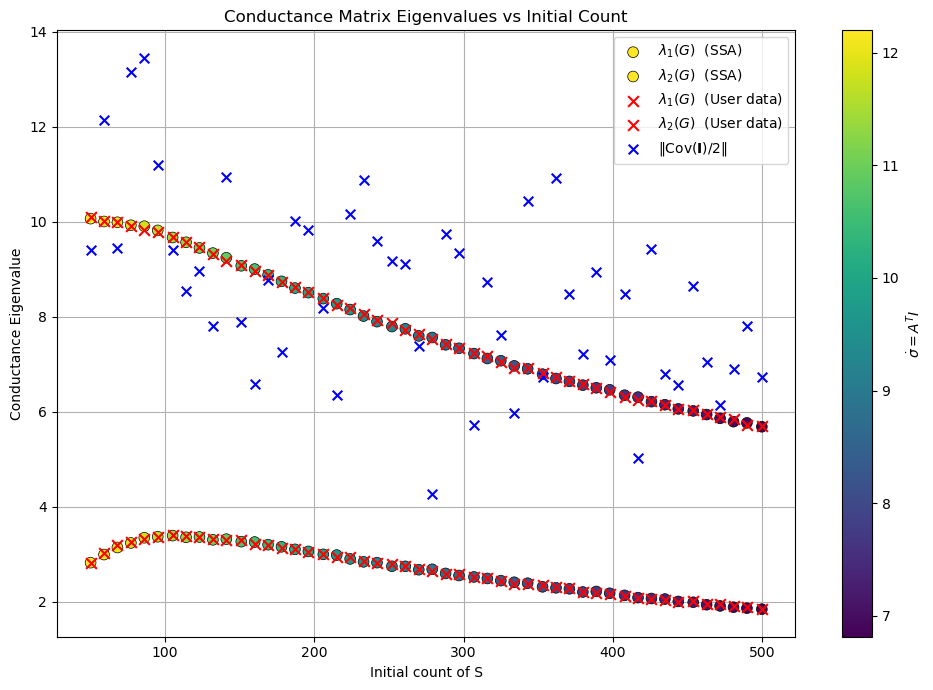

In [11]:
# And again run the sim over many values of a specified species to see the conductance changes (let's try 'S' and 'Nb', as these
# are external species. This is indexes = 8,9 (varying over the same quantity). And lets ignore covariance for now.

# Run the sweep

SIM3.run_IF_sweep(
    
        species_index=[8,9],
        count_values=[np.linspace(50,500,50,dtype='int'),np.linspace(50,500,50,dtype='int')],
        total_iterations=50, 
        covariance_reaction_indices=[5,7],   
        verbose=True)


# Compute the conductance and plot.

SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)

SIM3.plot_conductance(
        analytical_G=eigenvalues,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=False
    )

# Trying to do it without simulating the joimnt module first to find the Na

In [ ]:
# import numpy as np


def compute_species_flux(stoich_row, reaction_currents):

    return np.dot(stoich_row, reaction_currents)



def run_module_flux(ssa_runner, stoich_row, species_index, Na_value, iterations):

    pops = np.array(ssa_runner.initial_counts, dtype=float)

    flux_sum = 0.0

    for _ in range(iterations):

        pops[species_index] = Na_value

        ssa_runner.run_SSA_and_plot_counts(
            store_trajectories=False,
            starting_pops=pops
        )

        flux_sum += compute_species_flux(
            stoich_row,
            ssa_runner.average_reaction_currents
        )

    return flux_sum / iterations





In [ ]:
import numpy as np
from scipy.optimize import brentq


def find_Na_star_brent(
    module1_runner,
    module2_runner,
    Na_index_mod1,
    Na_index_mod2,
    Na_low,
    Na_high,
    iterations_per_eval=1,
    tol=1e-8,
):
    # Precompute stoichiometry rows
    stoich1 = np.asarray(module1_runner.module.stoich_matrix, dtype=float)[Na_index_mod1]
    stoich2 = np.asarray(module2_runner.module.stoich_matrix, dtype=float)[Na_index_mod2]

    # Function whose root we want: flux(mod1) + flux(mod2)
    def F(Na):
        J1 = run_module_flux(
            module1_runner, stoich1, Na_index_mod1, Na, iterations_per_eval
        )
        J2 = run_module_flux(
            module2_runner, stoich2, Na_index_mod2, Na, iterations_per_eval
        )

        
        return J1 + J2

    # Use Brent's method to find the root
    Na_star = brentq(F, Na_low, Na_high, xtol=tol)

    
    return Na_star

# SCRIPT TO FIND THE NESS VALUES OF Na VIA SOLVING Flux(Module1) + Flux(Module2) = 0 =========================================

Na_index_mod1 = SIM1.species_names.index("Na")
Na_index_mod2 = SIM2.species_names.index("Na")

Na_stars = []

t1_find_Na_SS = time.time()

# for S,Nb in zip(np.linspace(50,500,50,dtype=int), np.linspace(50,500,50,dtype=int)):

#     mod1SIM = RunSSA(module1_for_simulating, [350, 350, 350, S, 50], rates, simulation_length, burn_in_time)
#     mod2SIM = RunSSA(module2_for_simulating, [350, 350, 350, 350, 50, Nb, 50, 50], rates2, simulation_length, burn_in_time)

#     Na_star = find_Na_star_brent(
#         mod1SIM,
#         mod2SIM,
#         Na_index_mod1,
#         Na_index_mod2,
#         Na_low=20,
#         Na_high=600
#     )

#     Na_stars.append(Na_star)
#     print(Na_star)

t2_find_Na_SS = time.time()
# RUN THE DATA FOR FINDING MICROSCOPIC I AND F FOR MODULES SEPERATELY =========================================

time1_modular_approach = time.time()

SIM1.run_IF_sweep(

        species_index=[3,4],
        count_values=[np.linspace(50,500,50,dtype='int'), Na_stars],
        total_iterations=300, 
        covariance_reaction_indices=[0],   
        verbose=True)



SIM2.run_IF_sweep(

        species_index=[4,5],
        count_values=[Na_stars, np.linspace(50,500,50,dtype='int')],
        total_iterations=300, 
        covariance_reaction_indices=[2,4],   
        verbose=True)

# COMPUTE THE CONDUCTANCES OF THE SEPERATE MODULES =========================================

module1_conductances, _ = SIM1.compute_conductances(analytical_currents=None, analytical_forces=None)

module2_conductances, _ = SIM2.compute_conductances(analytical_currents=None, analytical_forces=None)

# COMBINE THE CONDUCTANCES VIA PAPER ALGEBRA =========================================

module3 = CombiningModules(module1_for_simulating, module2_for_simulating, module1_conductances, module2_conductances)

combined_Gs = module3.numerical_combined_fundamental_CMs

# FIND THE EIGENVALUES OF THIS MATRIX =========================================

analytical_G_np = np.array(combined_Gs, dtype=float)
eigenvalues = np.array([np.linalg.eigvals(analytical_G_np[i]) 
                            for i in range(analytical_G_np.shape[0])])

eigenvalues

time2_modular_approach = time.time()

# NOW SIMULATE THE JOINT SM MATRIX =========================================


m3 = CombiningModules(module1_for_simulating,module2_for_simulating,left_mod_numerical_CM=None,right_mod_numerical_CM=None) # order matters! Require Left feeds into Right

module3_for_simulating = ModuleProperties(m3.stoich_matrix, m3.num_internal_species, m3.species_names)

# Create combined rates and counts

combined_initial_counts, combined_rates = m3.build_combined_initial_counts_and_rates(
    left_initial_counts  = initial_counts,
    right_initial_counts = initial_counts2,
    left_rates = rates,
    right_rates = rates2
)

SIM3 = RunSSA(module3_for_simulating, combined_initial_counts, combined_rates, 800 , 200)

time1_direct_approach = time.time()

SIM3.run_IF_sweep(
    
        species_index=[8,9],
        count_values=[np.linspace(50,500,50,dtype='int'),np.linspace(50,500,50,dtype='int')],
        total_iterations=300, 
        covariance_reaction_indices=[5,7],   
        verbose=True)


SIM3.compute_conductances(analytical_currents=None, analytical_forces=None)

time2_direct_approach = time.time()

# PLOT AND COMPARE COMBINED DATA VS JOINT SM DATA =========================================

SIM3.plot_conductance(
        analytical_G=eigenvalues,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=False
    )

# PRINT TIMES TAKEN
print(f'Finding NESS Na values: t = {t2_find_Na_SS - t1_find_Na_SS}')
print(f'Modular: t = {time2_modular_approach - time1_modular_approach}')
print(f'Direct: t = {time2_direct_approach - time1_direct_approach}')



=== Overlapping species detected ===
  ['Na']
These species appear in both modules and are now internal.
Please enter a single initial count for each:

  Species 'Na':
    Left  module value : 50
    Right module value : 50
  Invalid input. Please enter a number.
  Invalid input. Please enter a number.

=== Combined initial counts ===
  [0] Ea           : 350
  [1] EaS          : 350
  [2] EaS2         : 350
  [3] Na           : 0.0 ← user entered
  [4] Eb           : 350
  [5] EbF          : 350
  [6] EbW          : 350
  [7] Eb*          : 350
  [8] S            : 50
  [9] Nb           : 50
  [10] F            : 50
  [11] W            : 50

=== Combined rates ===
  Reaction  1 (left ) : k+ = 0.0005,  k- = 0.08
  Reaction  2 (left ) : k+ = 0.06,  k- = 0.0002
  Reaction  3 (left ) : k+ = 0.0012,  k- = 0.05
  Reaction  4 (right) : k+ = 0.001,  k- = 0.1
  Reaction  5 (right) : k+ = 0.1,  k- = 0.05
  Reaction  6 (right) : k+ = 0.15,  k- = 0.001
  Reaction  7 (right) : k+ = 0.001,  k- = 0

RuntimeError: No sweep data found. Call run_IF_sweep() first.

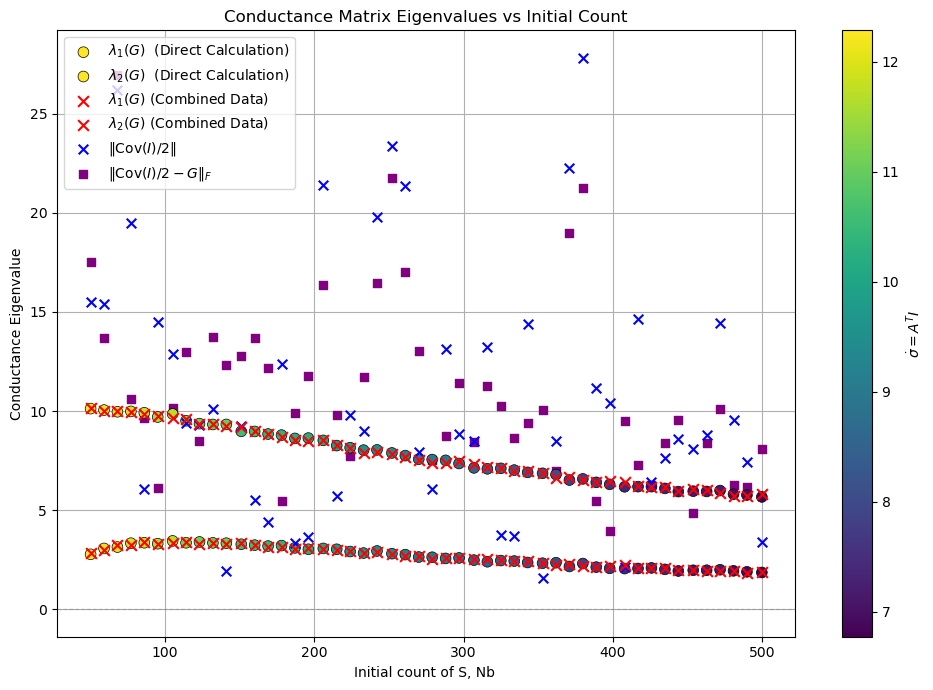

In [8]:
SIM3.plot_conductance(
        analytical_G=eigenvalues,
        marker_size=60,
        cmap='viridis',
        fit_order=2,
        show_covariance=True,
        show_difference=True
    )